# **Homework 4**
Name: Maddox Guthrie \
Id: 12184185

# 1.1 Exercise 1: Floating-Point Approximation


## 1.1.1 Floating-Point Rounding Function

In [1]:
import math

In [2]:
def floating_approx(x):
    p, emin, emax = 16, -100, 100
    sign = -1 if x < 0 else 1
    f, k = math.frexp(abs(x))
    m, e = 2 * f, k - 1
    n = round(m * 2 ** (p - 1))
    if n == 2 ** p:
        n //= 2
        e += 1
    if e > emax:
        return sign * math.inf
    if e < emin:
        return 0.0
    return sign * math.ldexp(n, e - (p - 1))

## 1.1.2 Relative Error Bound

In [3]:
import numpy as np
import matplotlib.pyplot as plt

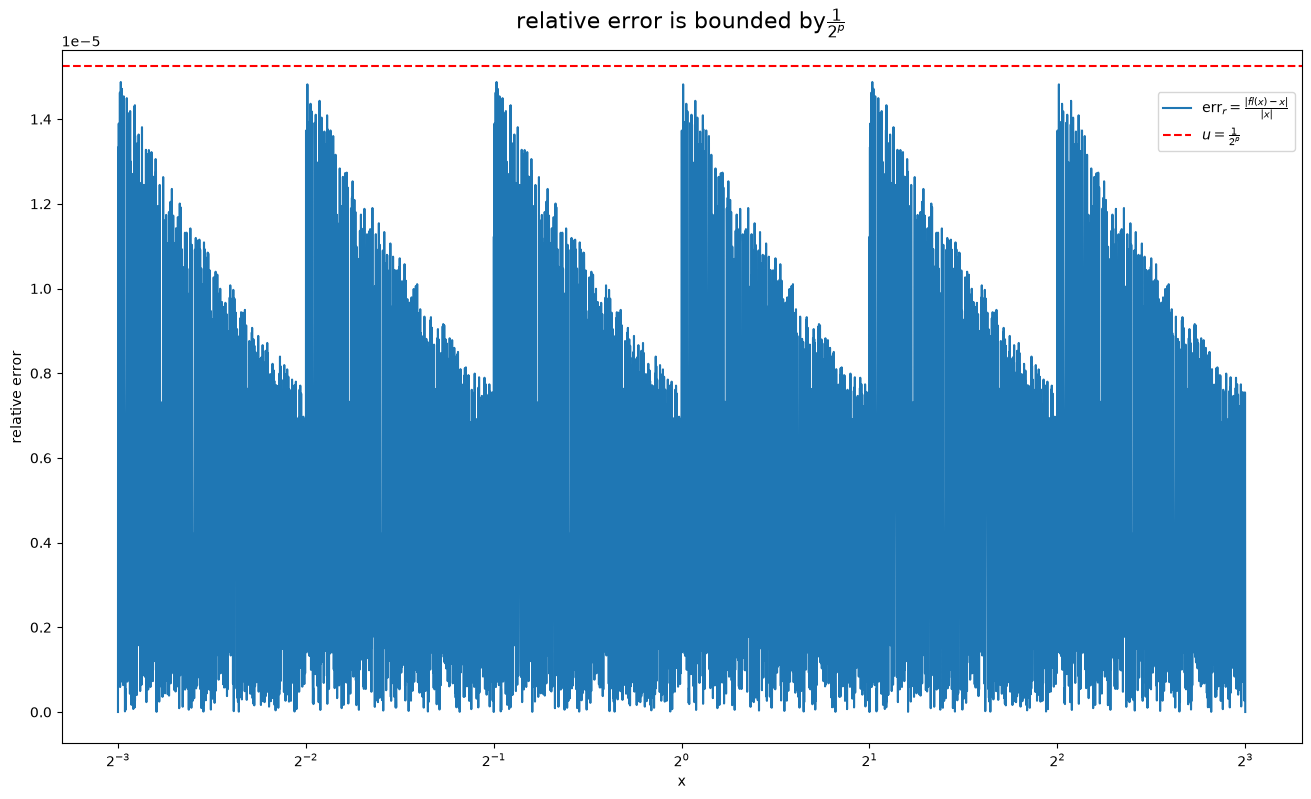

In [4]:
p = 16
u = 1 / 2 ** p

x = np.logspace(-3, 3, 10000, base=2)
err = [abs(floating_approx(x) - x) / abs(x) for x in x]

fig, ax = plt.subplots(figsize=(16, 9))
plt.plot(x, err, label=r'$\text{err}_r = \frac{|fl(x) - x|}{|x|}$')
plt.axhline(u, color='r', linestyle='--', label=r'$u = \frac{1}{2^p}$')
ax.set_xscale('log', base=2)

plt.xlabel('x')
plt.ylabel('relative error')
plt.title(r'$\text{relative error is bounded by} \frac{1}{2^p}$', fontsize=16, pad=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 0.95))

plt.show()

# 1.2 Exercise 2: Numerical Cancellation and Taylor Approximation

## 1.2.1 (a) Direct Evaluation

In [5]:
x_vals = np.array([])

for k in range(4, 17):
    x = 10.0 ** -k
    fx = (x - math.sin(x)) / (x ** 3)
    x_vals = np.append(x_vals, fx)

print(x_vals)

[0.16666666 0.16666728 0.16665373 0.17205357 0.         0.
 0.         0.         0.         0.         0.         0.
 0.        ]


## 1.2.2 (b) Explanation of the Numerical Issue

When $x$ is sufficiently small, $\sin(x) \approx x - \frac{x^3}{6}$, so $x$ and $\sin(x)$ are very close. The subtraction in the numerator, $x - \sin(x)$, begins to cancel out the leading digits of both values, and what is left is just rounding error. Each value has a relative error of about $1 \cdot 10^{-16}$, so $\sin(x)$ is off by about $x \cdot 10^{-16}$, while the true difference is only about $\frac{x^3}{6}$. After dividing by $x^3$, the relative error is about $\frac{6 \cdot 10^{-16}}{x^2}$, which grows as $x$ shrinks. For very small $x$, $\sin(x)$ rounds to $x$, so the numerator is 0 and $f(x) = 0$.

## 1.2.3 (c) Improved Formula Using a Taylor Expansion

$x - \sin(x) = \frac{x^3}{6} - \frac{x^5}{120} + \ldots$, so $f(x) = \frac{x - \sin(x)}{x^3} = \frac{1}{6} - \frac{x^2}{120}$

In [6]:
x_vals_2 = np.array([])

for k in range(4, 17):
    x = 10.0 ** -k
    fx = (1/6) - (x ** 2 / 120)
    x_vals_2 = np.append(x_vals_2, fx)

print(x_vals_2)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.16666667]


This version is much more accurate, with the value staying stable at 0.16666667 for all iterations, unlike the previous version that computed $\sin$, which became unstable after 1 iteration and collapsed to 0.0 after 4 iterations. The new values match $\frac{1}{6}$, which confirms they are correct.

# 1.3 Exercise 3: Visualizing Functions and Coordinate Systems

## 1.3.1 Plot multiple functions on the same axis

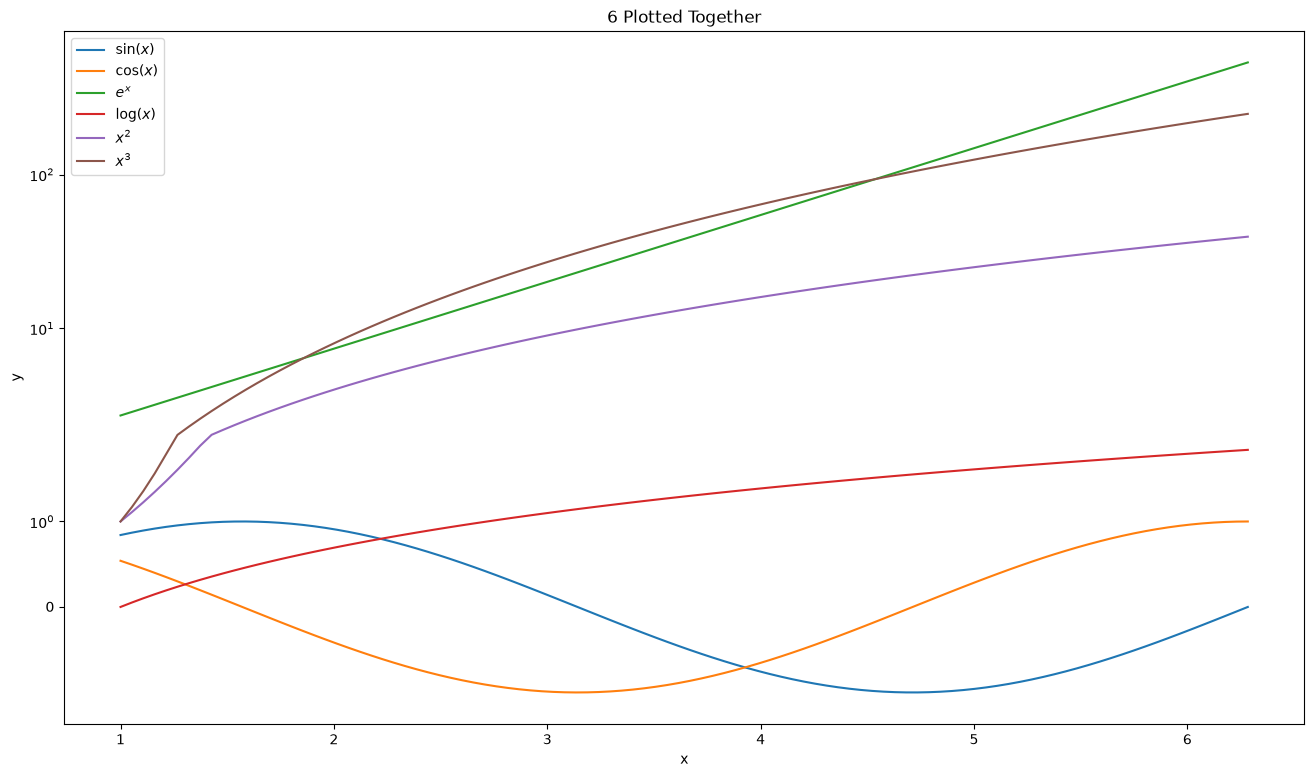

In [7]:
x = np.linspace(1, 2*math.pi, 100)

sin = np.sin(x)
cos = np.cos(x)
ex = np.exp(x)
log = np.log(x)
x2 = np.square(x)
x3 = np.power(x, 3)

fig, ax = plt.subplots(figsize=(16, 9))
plt.yscale('symlog')

plt.plot(x, sin, label=r'$\sin(x)$')
plt.plot(x, cos, label=r'$\cos(x)$')
plt.plot(x, ex, label=r'$e^x$')
plt.plot(x, log, label=r'$\log(x)$')
plt.plot(x, x2, label=r'$x^2$')
plt.plot(x, x3, label=r'$x^3$')

plt.xlabel('x')
plt.ylabel('y')
plt.title('6 Plotted Together')
plt.legend()

plt.show()

## 1.3.2 grid. Plot the same functions on a 2 × 3 grid

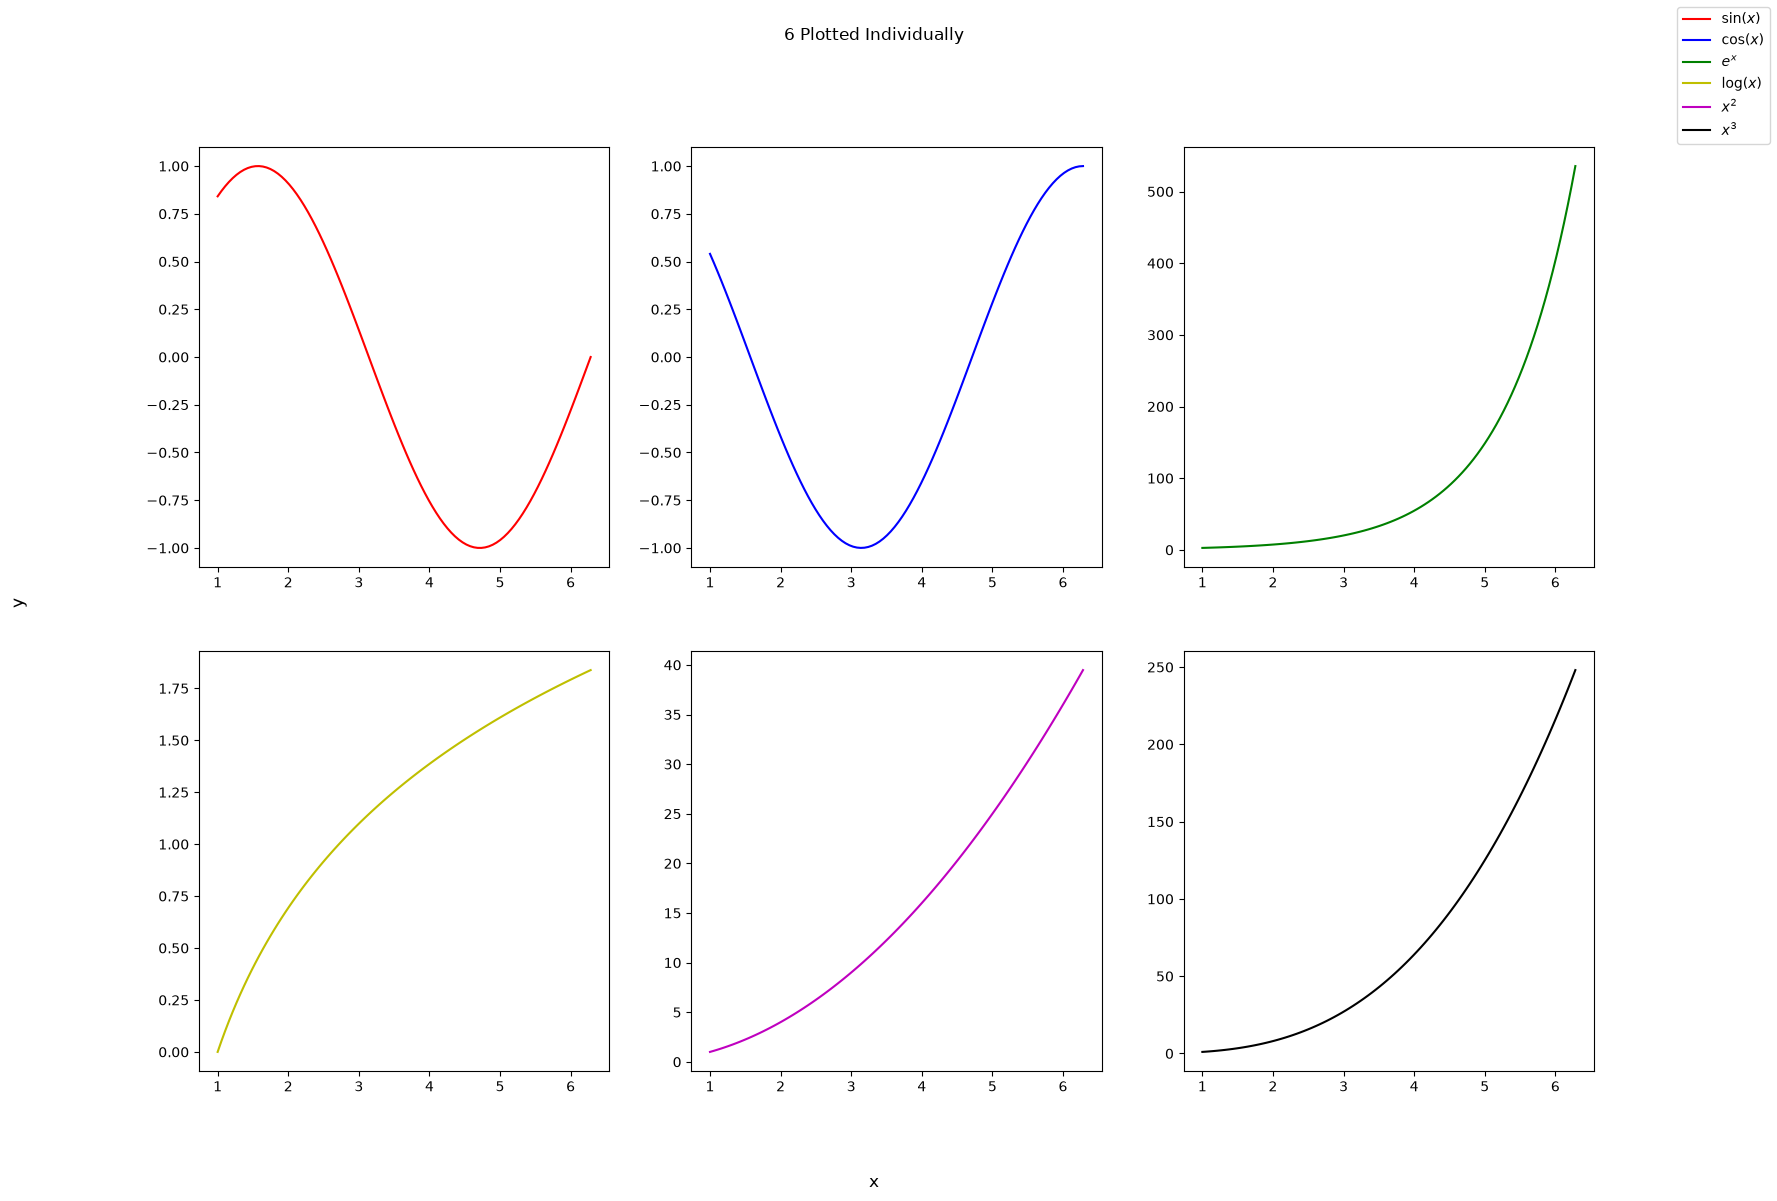

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

axs[0, 0].plot(x, sin, label=r'$\sin(x)$', color='r')
axs[0, 1].plot(x, cos, label=r'$\cos(x)$', color='b')
axs[0, 2].plot(x, ex, label=r'$e^x$', color='g')
axs[1, 0].plot(x, log, label=r'$\log(x)$', color='y')
axs[1, 1].plot(x, x2, label=r'$x^2$', color='m')
axs[1, 2].plot(x, x3, label=r'$x^3$', color='k')

fig.suptitle('6 Plotted Individually')
fig.supxlabel('x')
fig.supylabel('y')
fig.legend()

plt.show()

## 1.3.3 Cartesian vs Polar plots

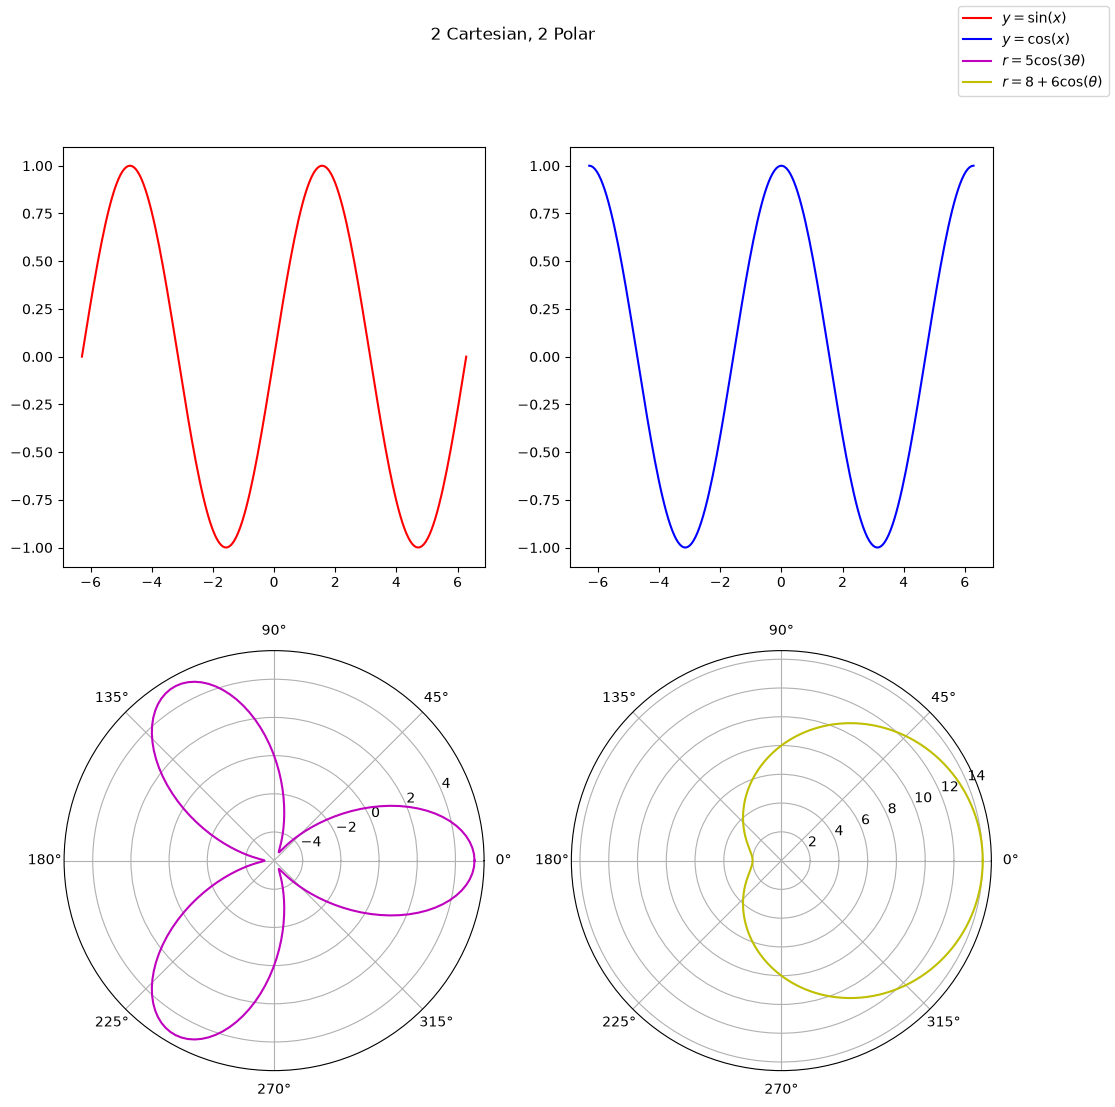

In [9]:
x = np.linspace(-2*np.pi, 2*np.pi, 200)
theta = np.linspace(0, 2*np.pi, 200)

y1 = np.sin(x)
y2 = np.cos(x)

r1 = 5*np.cos(3*theta)
r2 = 8 + 6*np.cos(theta)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].plot(x, y1, label=r"$y = \sin(x)$", color='r')
axs[0, 1].plot(x, y2, label=r"$y = \cos(x)$", color='b')

ax3 = plt.subplot(2, 2, 3, projection="polar")
ax3.plot(theta, r1, label=r"$r = 5\cos(3\theta)$", color='m')
axs[1, 0].set_axis_off()

ax4 = plt.subplot(2, 2, 4, projection="polar")
ax4.plot(theta, r2, label=r"$r = 8 + 6\cos(\theta)$", color='y')
axs[1, 1].set_axis_off()

fig.suptitle('2 Cartesian, 2 Polar')
fig.legend()

plt.show()